In [11]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("../data/mattakelle_dataset.csv")

# basic cleaning
df = df.drop_duplicates()
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# drop raw date columns
date_cols = [
    "month_date",
    "dolomite_applied_date",
    "last_fertilized_date",
    "last_weeding_date",
    "weeded_until_date"
]
df = df.drop(columns=[col for col in date_cols if col in df.columns])

# target
target = "yph_target"

X = df.drop(columns=[target]).copy()
y = df[target].copy()

# handle missing
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# encode categorical
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.columns = X_encoded.columns.str.replace(" ", "_")

# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [12]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

## METHOD 1 — Train vs Test (Overfit check)

In [16]:
from sklearn.metrics import r2_score

lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

def check_overfitting(model, name):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"\n{name} - Check overfit and underfit.ipynb:20")
    print("Train R2: - Check overfit and underfit.ipynb:21", round(train_r2, 4))
    print("Test  R2: - Check overfit and underfit.ipynb:22", round(test_r2, 4))

    gap = train_r2 - test_r2

    if gap > 0.1:
        print("⚠️ Overfitting - Check overfit and underfit.ipynb:27")
    elif train_r2 < 0.7 and test_r2 < 0.7:
        print("⚠️ Underfitting - Check overfit and underfit.ipynb:29")
    else:
        print("✅ Good Fit - Check overfit and underfit.ipynb:31")

# run
check_overfitting(xgb_model, "XGBoost")
check_overfitting(lgb_model, "LightGBM")
check_overfitting(cat_model, "CatBoost")


XGBoost - Check overfit and underfit.ipynb:20
Train R2: - Check overfit and underfit.ipynb:21 0.9857
Test  R2: - Check overfit and underfit.ipynb:22 0.9056
✅ Good Fit - Check overfit and underfit.ipynb:31

LightGBM - Check overfit and underfit.ipynb:20
Train R2: - Check overfit and underfit.ipynb:21 0.9736
Test  R2: - Check overfit and underfit.ipynb:22 0.8938
✅ Good Fit - Check overfit and underfit.ipynb:31

CatBoost - Check overfit and underfit.ipynb:20
Train R2: - Check overfit and underfit.ipynb:21 0.9264
Test  R2: - Check overfit and underfit.ipynb:22 0.8727
✅ Good Fit - Check overfit and underfit.ipynb:31


## METHOD 2 — Learning Curves

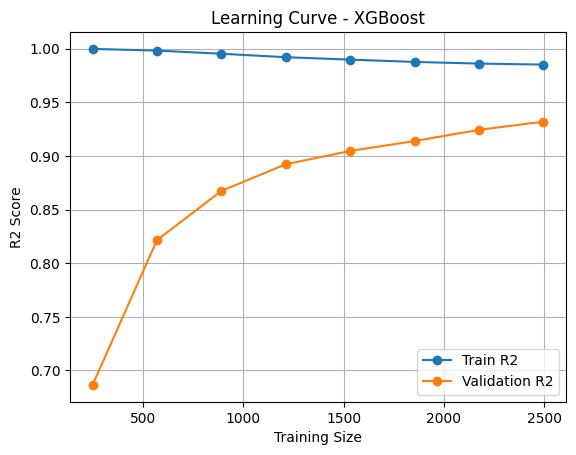

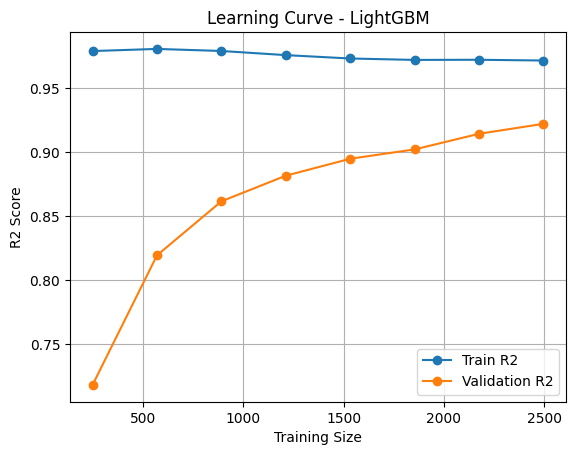

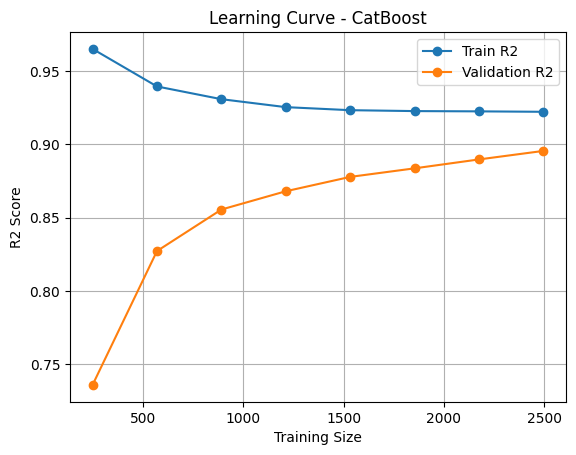

In [14]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, marker="o", label="Train R2")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation R2")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("R2 Score")

    plt.legend()
    plt.grid(True)
    plt.show()

# run
plot_learning_curve(xgb_model, "Learning Curve - XGBoost")
plot_learning_curve(lgb_model, "Learning Curve - LightGBM")
plot_learning_curve(cat_model, "Learning Curve - CatBoost")

## METHOD 3 — Cross Validation

In [15]:
from sklearn.model_selection import cross_val_score

def cross_validation_check(model, name):
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    print(f"\n{name} - Check overfit and underfit.ipynb:13")
    print("CV Scores: - Check overfit and underfit.ipynb:14", np.round(scores, 4))
    print("Mean R2 : - Check overfit and underfit.ipynb:15", round(scores.mean(), 4))
    print("Std Dev : - Check overfit and underfit.ipynb:16", round(scores.std(), 4))

    if scores.std() > 0.1:
        print("⚠️ Model unstable - Check overfit and underfit.ipynb:19")
    else:
        print("✅ Model stable - Check overfit and underfit.ipynb:21")

# run
cross_validation_check(xgb_model, "XGBoost")
cross_validation_check(lgb_model, "LightGBM")
cross_validation_check(cat_model, "CatBoost")


XGBoost - Check overfit and underfit.ipynb:13
CV Scores: - Check overfit and underfit.ipynb:14 [0.9237 0.949  0.94   0.9241 0.923 ]
Mean R2 : - Check overfit and underfit.ipynb:15 0.932
Std Dev : - Check overfit and underfit.ipynb:16 0.0106
✅ Model stable - Check overfit and underfit.ipynb:21

LightGBM - Check overfit and underfit.ipynb:13
CV Scores: - Check overfit and underfit.ipynb:14 [0.9171 0.9355 0.9327 0.9124 0.913 ]
Mean R2 : - Check overfit and underfit.ipynb:15 0.9221
Std Dev : - Check overfit and underfit.ipynb:16 0.0099
✅ Model stable - Check overfit and underfit.ipynb:21

CatBoost - Check overfit and underfit.ipynb:13
CV Scores: - Check overfit and underfit.ipynb:14 [0.89   0.9102 0.8993 0.8925 0.8841]
Mean R2 : - Check overfit and underfit.ipynb:15 0.8952
Std Dev : - Check overfit and underfit.ipynb:16 0.0089
✅ Model stable - Check overfit and underfit.ipynb:21


## XGBoost

## LightGBM

## CatBoost